# Cursos de Series de tiempo con *Machine Learning*
## Modulo. Supuesto 1: La Ausencia de Autocorrelacion(Independencia de Errores)
                        Elaborado por: Naren Castellon

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("./ferreteria.csv")
data = data.drop('Unnamed: 0', axis = 1)
data

,sku_id,ds,price_unit,promotion_active,season_factor,temperature_avg,rain_days,events_nearby,marketing_spend,competitor_price,...,store_visits,holiday_week,new_product_launch,lead_time_days,current_stock,supplier_delay_rate,customer_reviews_score,distribution_channels,previous_sku,demand_units
0,Martillo 16oz,2021-01-04,59.31,0,1.620537,21.948085,3,1,4472.923246,11.84,...,12007,1,0,21,1092,0.195272,3.5,3,Martillo 16oz,760
1,Martillo 16oz,2021-01-11,142.85,1,1.739316,14.436052,2,0,5735.450391,134.83,...,12084,0,0,21,220,0.134813,3.9,2,Martillo 16oz,1069
2,Martillo 16oz,2021-01-18,111.14,0,1.854605,27.699857,5,1,3000.000000,4.69,...,11969,0,0,30,2324,0.167410,3.7,3,"Tubos PVC 1/2""",830
3,Martillo 16oz,2021-01-25,91.81,0,1.964723,22.893538,3,1,12230.349623,136.45,...,11860,0,0,30,3803,0.150220,4.8,3,Martillo 16oz,1153
4,Martillo 16oz,2021-02-01,27.62,1,2.068065,23.743801,3,1,13927.295092,68.39,...,12009,0,0,21,446,0.194851,4.7,2,"Tornillos 2""",1691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910,"Tubos PVC 1/2""",2025-12-01,10.69,1,1.145395,27.189281,1,1,19878.001579,56.22,...,12128,0,0,21,2163,0.209632,3.9,2,"Tubos PVC 1/2""",805
3911,"Tubos PVC 1/2""",2025-12-08,44.44,1,1.260684,37.534838,5,1,6870.388964,135.40,...,12064,0,0,21,1447,0.202760,4.1,1,Sierra Circular,946
3912,"Tubos PVC 1/2""",2025-12-15,5.92,0,1.379463,29.792718,4,1,13711.792101,123.53,...,11885,0,1,30,1103,0.153815,3.8,2,"Tubos PVC 1/2""",755
3913,"Tubos PVC 1/2""",2025-12-22,146.86,0,1.500000,26.405390,3,0,13693.389767,124.23,...,11975,1,0,30,1468,0.199498,3.5,3,"Tubos PVC 1/2""",751


In [3]:
data['ds'] = pd.to_datetime(data['ds'])

# `Modelo con Regresion Lineal`

In [5]:
# Creamos una lista con todos los skus
skus = [
    'Martillo 16oz', 'Destornillador Phillips', 'Taladro Inalámbrico', 'Sierra Circular', 'Pintura Blanca 1Gal',
    'Cemento 50kg', 'Tornillos 2"', 'Clavos 3"', 'Cinta Métrica 5m', 'Nivel 1m',
    'Llave Ajustable', 'Brochas 2"', 'Lija Grano 120', 'Pegamento PVC', 'Tubos PVC 1/2"'
]

SKU                       | Durbin-Watson   | Estado del Supuesto
---------------------------------------------------------------------------
Martillo 16oz             | 0.5530          | ⚠️ Autocorr. Positiva
Destornillador Phillips   | 0.5198          | ⚠️ Autocorr. Positiva
Taladro Inalámbrico       | 0.5558          | ⚠️ Autocorr. Positiva
Sierra Circular           | 0.5405          | ⚠️ Autocorr. Positiva
Pintura Blanca 1Gal       | 0.6712          | ⚠️ Autocorr. Positiva
Cemento 50kg              | 0.4870          | ⚠️ Autocorr. Positiva
Tornillos 2"              | 0.8493          | ⚠️ Autocorr. Positiva
Clavos 3"                 | 0.5415          | ⚠️ Autocorr. Positiva
Cinta Métrica 5m          | 0.7075          | ⚠️ Autocorr. Positiva
Nivel 1m                  | 0.6015          | ⚠️ Autocorr. Positiva
Llave Ajustable           | 0.5560          | ⚠️ Autocorr. Positiva
Brochas 2"                | 0.6013          | ⚠️ Autocorr. Positiva
Lija Grano 120            | 0.5998        

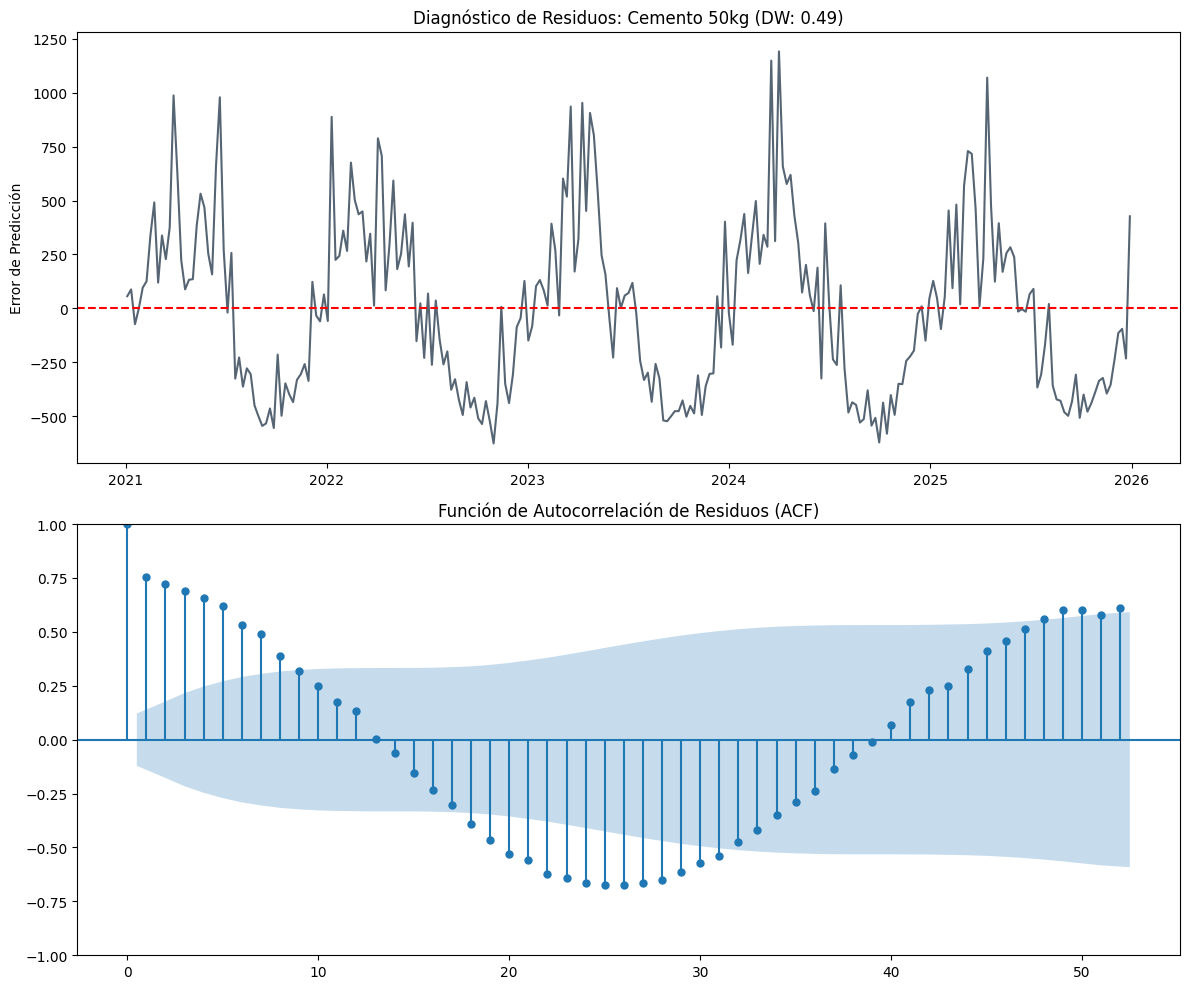

In [6]:


# --- PASO 2: PROCESAMIENTO ITERATIVO CON FILTRO POR SKU ---

resultados_diagnostico = []

print(f"{'SKU':<25} | {'Durbin-Watson':<15} | {'Estado del Supuesto'}")
print("-" * 75)

for sku in skus:
    # FILTRO CRÍTICO: Seleccionamos solo los datos del SKU actual
    df_sku = data[data['sku_id'] == sku].copy()
    
    # Preparación de variables para la regresión
    X = df_sku[['price_unit', 'economic_index']]
    X = sm.add_constant(X)
    y = df_sku['demand_units']
    
    # Ajuste del modelo OLS
    model = sm.OLS(y, X).fit()
    
    # Cálculo de residuos y estadístico de Durbin-Watson
    residuos = model.resid
    dw_stat = durbin_watson(residuos)
    
    # Clasificación del resultado
    if dw_stat < 1.6:
        estado = "⚠️ Autocorr. Positiva"
    elif dw_stat > 2.4:
        estado = "⚠️ Autocorr. Negativa"
    else:
        estado = "✅ Independiente"
        
    print(f"{sku:<25} | {dw_stat:<15.4f} | {estado}")
    
    # Almacenamos resultados para la visualización final
    resultados_diagnostico.append({
        'sku_id': sku,
        'dw_statistic': dw_stat,
        'status': estado,
        'residuals': residuos,
        'dates': df_sku['ds']
    })

# --- PASO 3: VISUALIZACIÓN DEL CASO MÁS CRÍTICO ---

resumen_df = pd.DataFrame(resultados_diagnostico)
peor_caso = resumen_df.loc[resumen_df['dw_statistic'].idxmin()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# A. Gráfico de Residuos
ax1.plot(peor_caso['dates'], peor_caso['residuals'], color='#2c3e50', alpha=0.8)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title(f"Diagnóstico de Residuos: {peor_caso['sku_id']} (DW: {peor_caso['dw_statistic']:.2f})")
ax1.set_ylabel("Error de Predicción")

# B. Correlograma ACF
plot_acf(peor_caso['residuals'], lags=52, ax=ax2)
ax2.set_title("Función de Autocorrelación de Residuos (ACF)")

plt.tight_layout()
plt.show()

## `Regresion lineal con forecast`

SKU                       | Durbin-Watson   | Estado del Supuesto
---------------------------------------------------------------------------
Martillo 16oz             | 0.5530          | ⚠️ Autocorr. Positiva
Destornillador Phillips   | 0.5198          | ⚠️ Autocorr. Positiva
Taladro Inalámbrico       | 0.5558          | ⚠️ Autocorr. Positiva
Sierra Circular           | 0.5405          | ⚠️ Autocorr. Positiva
Pintura Blanca 1Gal       | 0.6712          | ⚠️ Autocorr. Positiva
Cemento 50kg              | 0.4870          | ⚠️ Autocorr. Positiva
Tornillos 2"              | 0.8493          | ⚠️ Autocorr. Positiva
Clavos 3"                 | 0.5415          | ⚠️ Autocorr. Positiva
Cinta Métrica 5m          | 0.7075          | ⚠️ Autocorr. Positiva
Nivel 1m                  | 0.6015          | ⚠️ Autocorr. Positiva
Llave Ajustable           | 0.5560          | ⚠️ Autocorr. Positiva
Brochas 2"                | 0.6013          | ⚠️ Autocorr. Positiva
Lija Grano 120            | 0.5998        

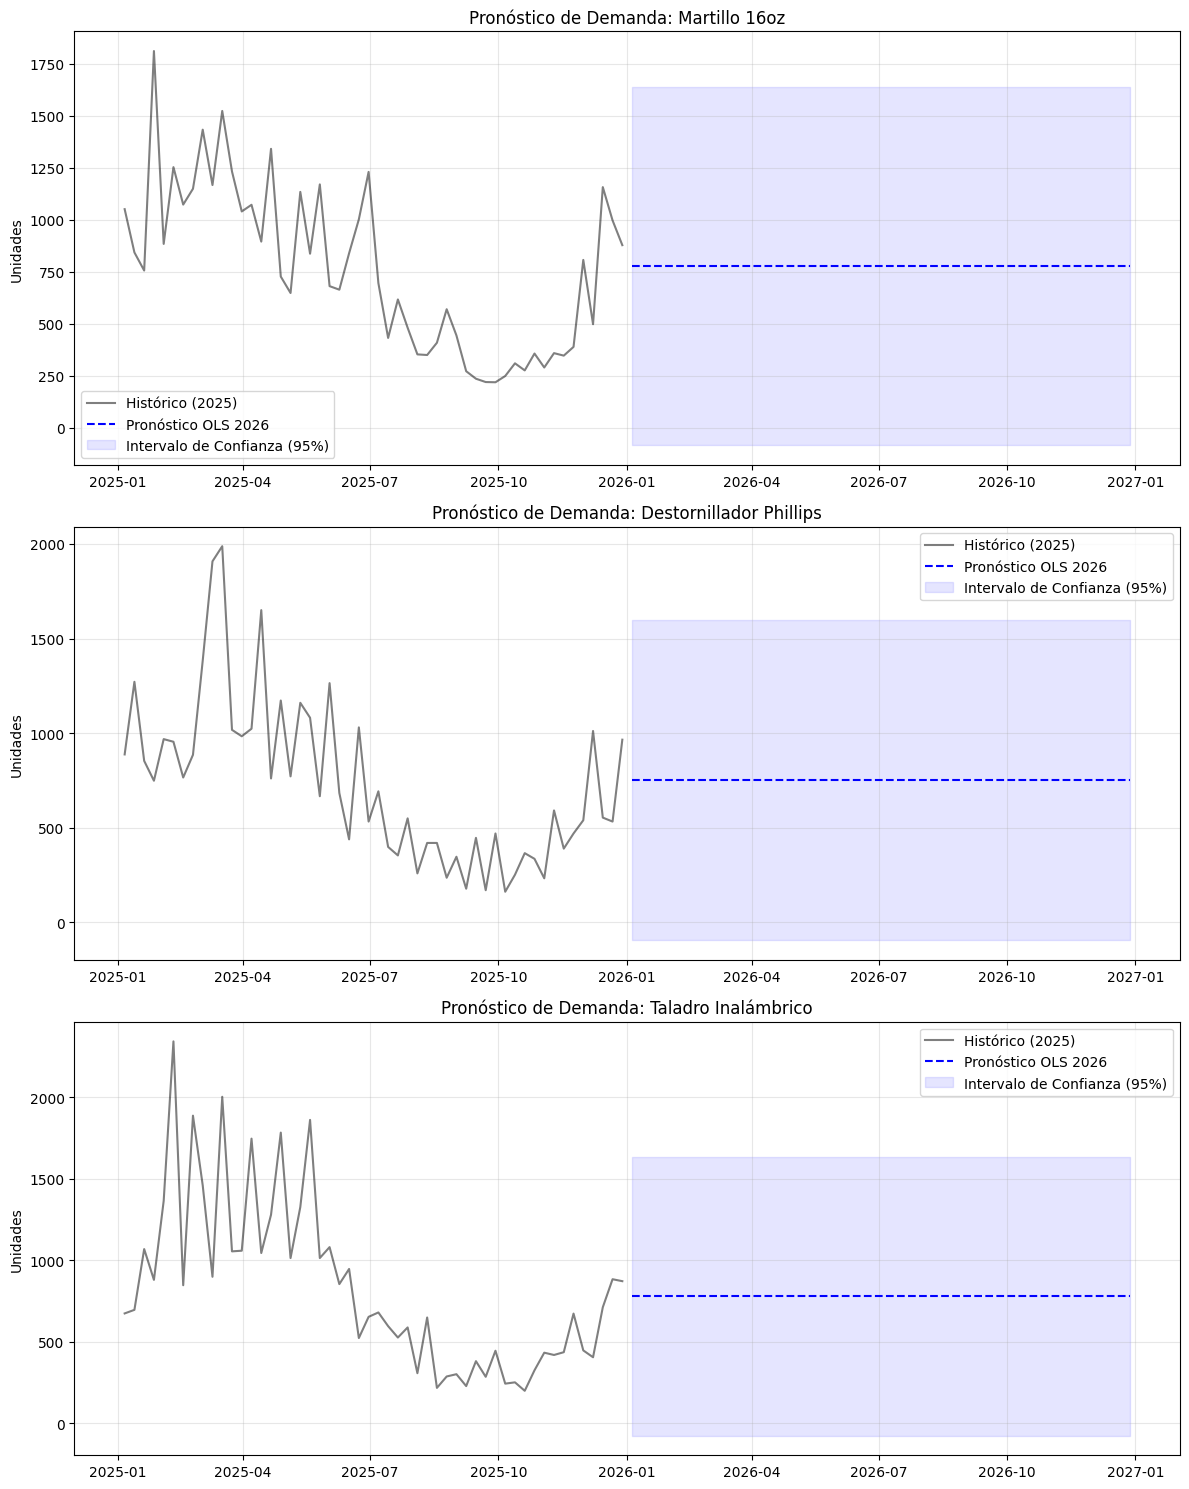

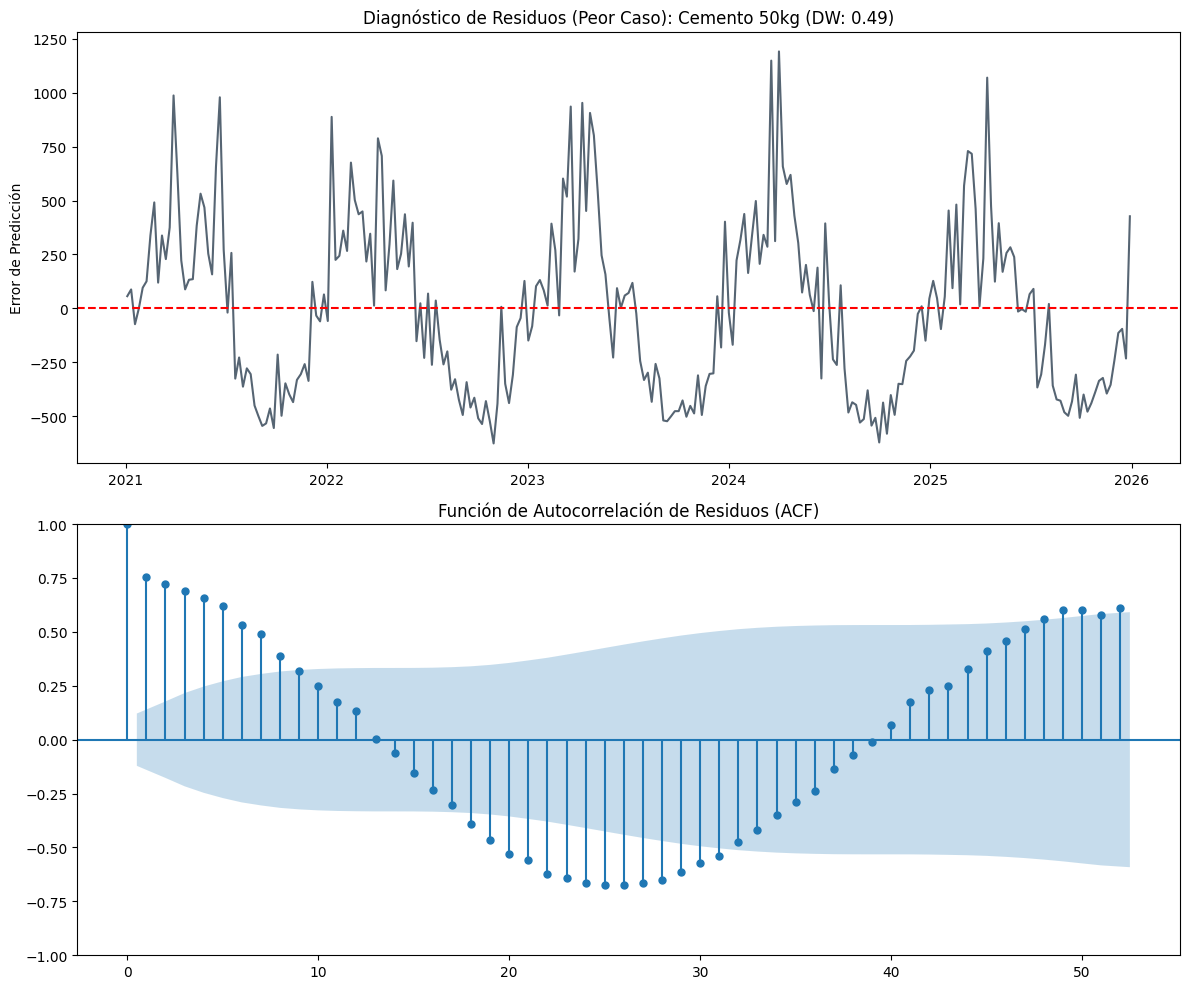

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

# --- PASO 0: CONFIGURACIÓN Y GENERACIÓN DE DATOS (Simulación Maestro) ---
np.random.seed(42)
dates = pd.date_range('2018-01-01', '2025-12-31', freq='W-MON')
n_periods = len(dates)

skus = [
    'Martillo 16oz', 'Destornillador Phillips', 'Taladro Inalámbrico', 'Sierra Circular', 'Pintura Blanca 1Gal',
    'Cemento 50kg', 'Tornillos 2"', 'Clavos 3"', 'Cinta Métrica 5m', 'Nivel 1m',
    'Llave Ajustable', 'Brochas 2"', 'Lija Grano 120', 'Pegamento PVC', 'Tubos PVC 1/2"'
]



# --- PASO 2: PROCESAMIENTO ITERATIVO CON FILTRO POR SKU Y FORECAST ---

resultados_diagnostico = []
pronosticos_lista = {} # Para guardar las predicciones y graficar

print(f"{'SKU':<25} | {'Durbin-Watson':<15} | {'Estado del Supuesto'}")
print("-" * 75)

# Definimos el horizonte de pronóstico (Todo 2026)
future_dates = pd.date_range('2026-01-05', periods=52, freq='W-MON')

for sku in skus:
    # FILTRO CRÍTICO: Seleccionamos solo los datos del SKU actual
    df_sku = data[data['sku_id'] == sku].copy()
    
    # 1. Preparación de variables para el entrenamiento
    X = df_sku[['price_unit', 'economic_index']]
    X = sm.add_constant(X)
    y = df_sku['demand_units']
    
    # 2. Ajuste del modelo OLS
    model = sm.OLS(y, X).fit()
    
    # 3. Cálculo de residuos y estadístico de Durbin-Watson
    residuos = model.resid
    dw_stat = durbin_watson(residuos)
    
    # Clasificación del estado del supuesto
    if dw_stat < 1.6:
        estado = "⚠️ Autocorr. Positiva"
    elif dw_stat > 2.4:
        estado = "⚠️ Autocorr. Negativa"
    else:
        estado = "✅ Independiente"
        
    print(f"{sku:<25} | {dw_stat:<15.4f} | {estado}")
    
    # 4. GENERACIÓN DEL FORECAST (2026)
    # Creamos escenarios futuros para las variables exógenas (promedios)
    X_future = pd.DataFrame({
        'const': 1.0,
        'price_unit': [df_sku['price_unit'].mean()] * 52,
        'economic_index': [df_sku['economic_index'].mean()] * 52
    }, index=future_dates)
    
    # Realizamos la predicción puntual y el intervalo de confianza
    predictions = model.get_prediction(X_future)
    df_pred = predictions.summary_frame(alpha=0.05) # 95% confianza
    
    # Almacenamos resultados para la visualización final
    resultados_diagnostico.append({
        'sku_id': sku,
        'dw_statistic': dw_stat,
        'status': estado,
        'residuals': residuos,
        'dates': df_sku['ds']
    })
    
    pronosticos_lista[sku] = {
        'forecast': df_pred['mean'],
        'lower': df_pred['obs_ci_lower'],
        'upper': df_pred['obs_ci_upper'],
        'history': df_sku.tail(52) # Guardamos el último año para la gráfica
    }

# --- PASO 3: VISUALIZACIÓN DEL PRONÓSTICO (3 EJEMPLOS) ---

skus_ejemplo = skus[:3]
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for i, sku in enumerate(skus_ejemplo):
    p = pronosticos_lista[sku]
    ax = axes[i]
    
    # Graficar Histórico
    ax.plot(p['history']['ds'], p['history']['demand_units'], label='Histórico (2025)', color='black', alpha=0.5)
    
    # Graficar Pronóstico
    ax.plot(future_dates, p['forecast'], label='Pronóstico OLS 2026', color='blue', linestyle='--')
    
    # Graficar Intervalos de Confianza
    ax.fill_between(future_dates, p['lower'], p['upper'], color='blue', alpha=0.1, label='Intervalo de Confianza (95%)')
    
    ax.set_title(f"Pronóstico de Demanda: {sku}")
    ax.set_ylabel("Unidades")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- PASO 4: VISUALIZACIÓN DEL CASO MÁS CRÍTICO (Diagnóstico de Residuos) ---

resumen_df = pd.DataFrame(resultados_diagnostico)
peor_caso = resumen_df.loc[resumen_df['dw_statistic'].idxmin()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# A. Gráfico de Residuos
ax1.plot(peor_caso['dates'], peor_caso['residuals'], color='#2c3e50', alpha=0.8)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title(f"Diagnóstico de Residuos (Peor Caso): {peor_caso['sku_id']} (DW: {peor_caso['dw_statistic']:.2f})")
ax1.set_ylabel("Error de Predicción")

# B. Correlograma ACF
plot_acf(peor_caso['residuals'], lags=52, ax=ax2)
ax2.set_title("Función de Autocorrelación de Residuos (ACF)")

plt.tight_layout()
plt.show()

## `Sarimax`

In [9]:

# --- 2. PROCESAMIENTO ITERATIVO CON SARIMAX ---

resultados_finales = {}
resultados_diagnostico = [] # Lista solicitada para almacenar métricas de validación

print(f"{'SKU':<25} | {'DW Stat':<10} | {'AIC':<10} | {'Estado'}")
print("-" * 65)

for sku in skus:
    # Filtrar datos por SKU
    df_sku = data[data['sku_id'] == sku].set_index('ds')

    # Definir variables exógenas
    exog = df_sku[['price_unit', 'economic_index']]
    
    try:
        # Configurar y entrenar SARIMAX
        model = SARIMAX(
            df_sku['demand_units'],
            exog=exog,
            order=(1, 0, 0),
            seasonal_order=(0, 0, 0, 52),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        # Validación de residuos (Supuesto de Independencia)
        dw_stat = durbin_watson(results.resid)
        estado = "✅ OK" if 1.7 < dw_stat < 2.3 else "⚠️ Revisar"
        
        print(f"{sku:<25} | {dw_stat:<10.2f} | {results.aic:<10.2f} | {estado}")
        
        # --- ALMACENAMIENTO DE RESULTADOS DE DIAGNÓSTICO (ESTRUCTURA SOLICITADA) ---
        resultados_diagnostico.append({
            'sku_id': sku,
            'dw_statistic': dw_stat,
            'status': estado,
            'residuals': results.resid,
            'dates': df_sku.index
        })

        # --- 3. PRONÓSTICO 2026 ---
        future_dates = pd.date_range('2026-01-05', periods=52, freq='W-MON')
        future_exog = pd.DataFrame({
            'price': [df_sku['price_unit'].mean()] * 52,
            'econ_idx': [df_sku['economic_index'].mean()] * 52
        }, index=future_dates)
        
        forecast_obj = results.get_forecast(steps=52, exog=future_exog)
        
        resultados_finales[sku] = {
            'forecast': forecast_obj.predicted_mean,
            'conf_int': forecast_obj.conf_int(),
            'history': df_sku['demand_units'].tail(52)
        }
        
    except Exception as e:
        print(f"{sku:<25} | Error en el modelo: {e}")



SKU                       | DW Stat    | AIC        | Estado
-----------------------------------------------------------------
Martillo 16oz             | 2.46       | 3698.77    | ⚠️ Revisar
Destornillador Phillips   | 2.45       | 3687.93    | ⚠️ Revisar
Taladro Inalámbrico       | 2.59       | 3702.41    | ⚠️ Revisar
Sierra Circular           | 2.74       | 3697.03    | ⚠️ Revisar
Pintura Blanca 1Gal       | 2.54       | 3726.21    | ⚠️ Revisar
Cemento 50kg              | 2.48       | 3637.30    | ⚠️ Revisar
Tornillos 2"              | 2.66       | 3782.45    | ⚠️ Revisar
Clavos 3"                 | 2.57       | 3721.24    | ⚠️ Revisar
Cinta Métrica 5m          | 2.48       | 3747.18    | ⚠️ Revisar
Nivel 1m                  | 2.56       | 3742.58    | ⚠️ Revisar
Llave Ajustable           | 2.60       | 3682.08    | ⚠️ Revisar
Brochas 2"                | 2.48       | 3721.59    | ⚠️ Revisar
Lija Grano 120            | 2.42       | 3706.65    | ⚠️ Revisar
Pegamento PVC             | 

In [10]:
df_diagnostico = pd.DataFrame(resultados_diagnostico)
df_diagnostico

,sku_id,dw_statistic,status,residuals,dates
0,Martillo 16oz,2.457424,⚠️ Revisar,ds 2021-01-04 -31.516612 2021-01-11 238....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
1,Destornillador Phillips,2.447529,⚠️ Revisar,ds 2021-01-04 -155.730722 2021-01-11 507....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
2,Taladro Inalámbrico,2.593178,⚠️ Revisar,ds 2021-01-04 11.061206 2021-01-11 332....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
3,Sierra Circular,2.738622,⚠️ Revisar,ds 2021-01-04 -155.505964 2021-01-11 400....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
4,Pintura Blanca 1Gal,2.536691,⚠️ Revisar,ds 2021-01-04 207.934239 2021-01-11 -198....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
5,Cemento 50kg,2.481331,⚠️ Revisar,ds 2021-01-04 100.842451 2021-01-11 106....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
6,"Tornillos 2""",2.655109,⚠️ Revisar,ds 2021-01-04 196.525119 2021-01-11 -286....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
7,"Clavos 3""",2.568364,⚠️ Revisar,ds 2021-01-04 -80.195833 2021-01-11 336....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
8,Cinta Métrica 5m,2.476429,⚠️ Revisar,ds 2021-01-04 -13.069926 2021-01-11 184....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."
9,Nivel 1m,2.564025,⚠️ Revisar,ds 2021-01-04 54.025312 2021-01-11 38....,"DatetimeIndex(['2021-01-04', '2021-01-11', '20..."


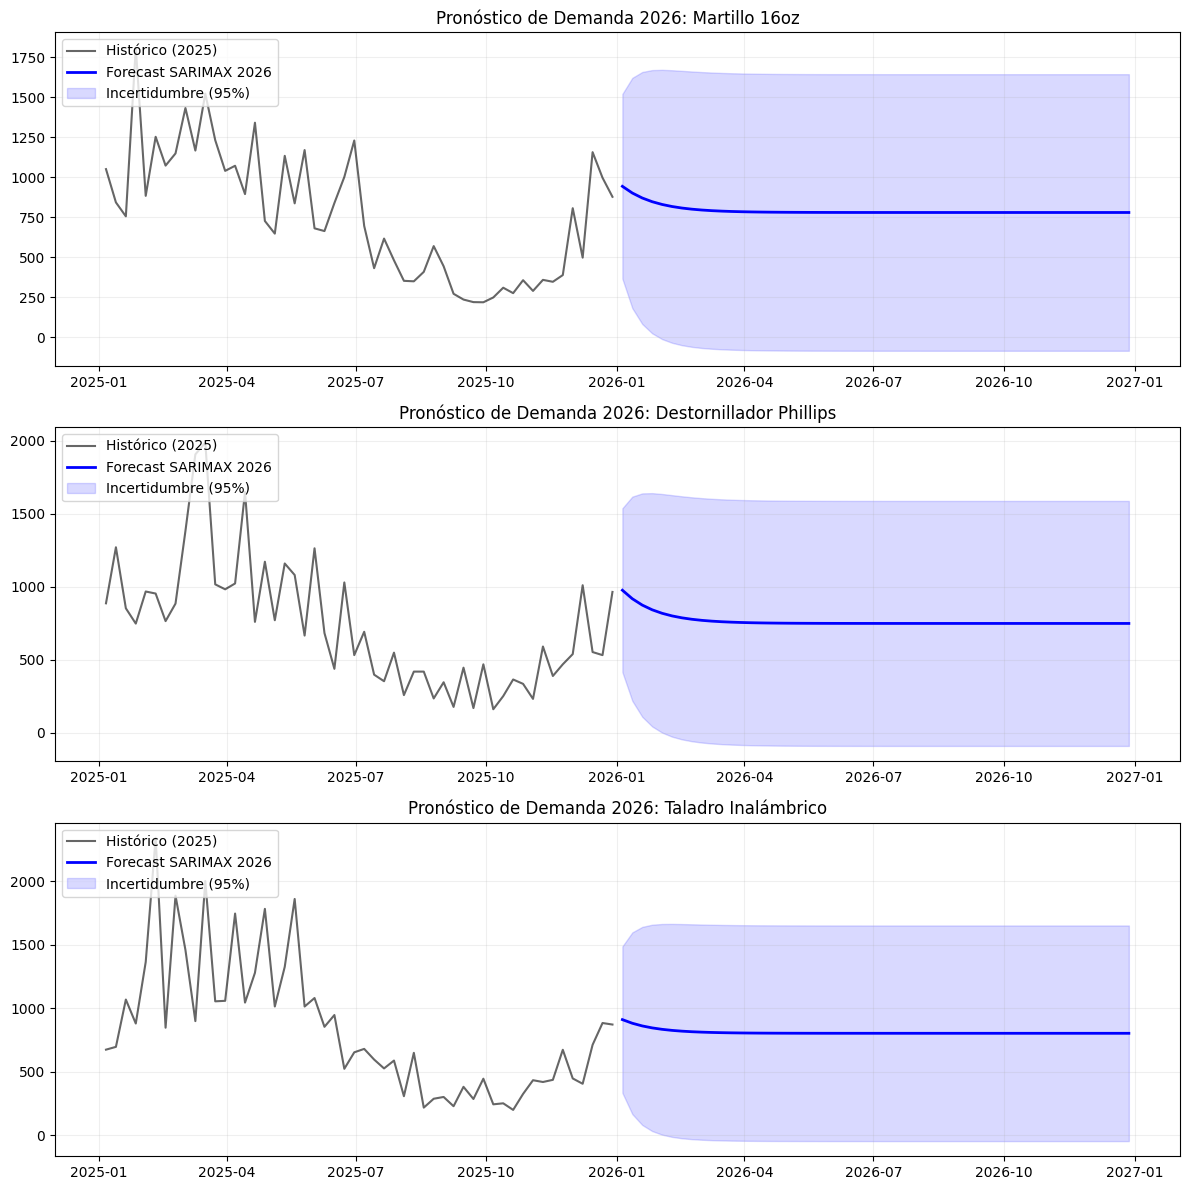


Proceso completado. La lista 'resultados_diagnostico' contiene los datos de validación para todos los SKUs.


In [11]:
# --- 4. VISUALIZACIÓN DE RESULTADOS ---

# Convertimos los diagnósticos a un DataFrame para fácil manipulación
df_diagnostico = pd.DataFrame(resultados_diagnostico)

# Ejemplo: Visualización del pronóstico para los primeros 3 SKUs
skus_to_plot = skus[:3]
fig, axes = plt.subplots(len(skus_to_plot), 1, figsize=(12, 4 * len(skus_to_plot)))

for i, sku in enumerate(skus_to_plot):
    data1 = resultados_finales[sku]
    ax = axes[i]
    
    ax.plot(data1['history'].index, data1['history'], label='Histórico (2025)', color='black', alpha=0.6)
    ax.plot(data1['forecast'].index, data1['forecast'], label='Forecast SARIMAX 2026', color='blue', lw=2)
    ax.fill_between(
        data1['forecast'].index, 
        data1['conf_int'].iloc[:, 0], 
        data1['conf_int'].iloc[:, 1], 
        color='blue', alpha=0.15, label='Incertidumbre (95%)'
    )
    
    ax.set_title(f"Pronóstico de Demanda 2026: {sku}")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\nProceso completado. La lista 'resultados_diagnostico' contiene los datos de validación para todos los SKUs.")

In [12]:
df_master = data.copy()

--- EJECUTANDO MODELO ORIGINAL ---
SKU                       | DW Stat    | AIC        | Estado
-----------------------------------------------------------------
Martillo 16oz             | 2.03       | 3660.61    | ✅ OK
Destornillador Phillips   | 2.00       | 3660.61    | ✅ OK
Taladro Inalámbrico       | 1.99       | 3660.61    | ✅ OK
Sierra Circular           | 2.05       | 3660.61    | ✅ OK
Pintura Blanca 1Gal       | 2.02       | 3660.61    | ✅ OK
Cemento 50kg              | 1.98       | 3660.61    | ✅ OK
Tornillos 2"              | 2.01       | 3660.61    | ✅ OK
Clavos 3"                 | 1.99       | 3660.61    | ✅ OK
Cinta Métrica 5m          | 1.99       | 3660.61    | ✅ OK
Nivel 1m                  | 2.01       | 3660.61    | ✅ OK
Llave Ajustable           | 2.00       | 3660.61    | ✅ OK
Brochas 2"                | 2.14       | 3660.61    | ✅ OK
Lija Grano 120            | 2.02       | 3660.61    | ✅ OK
Pegamento PVC             | 2.01       | 3660.61    | ✅ OK
Tubos PVC 1/

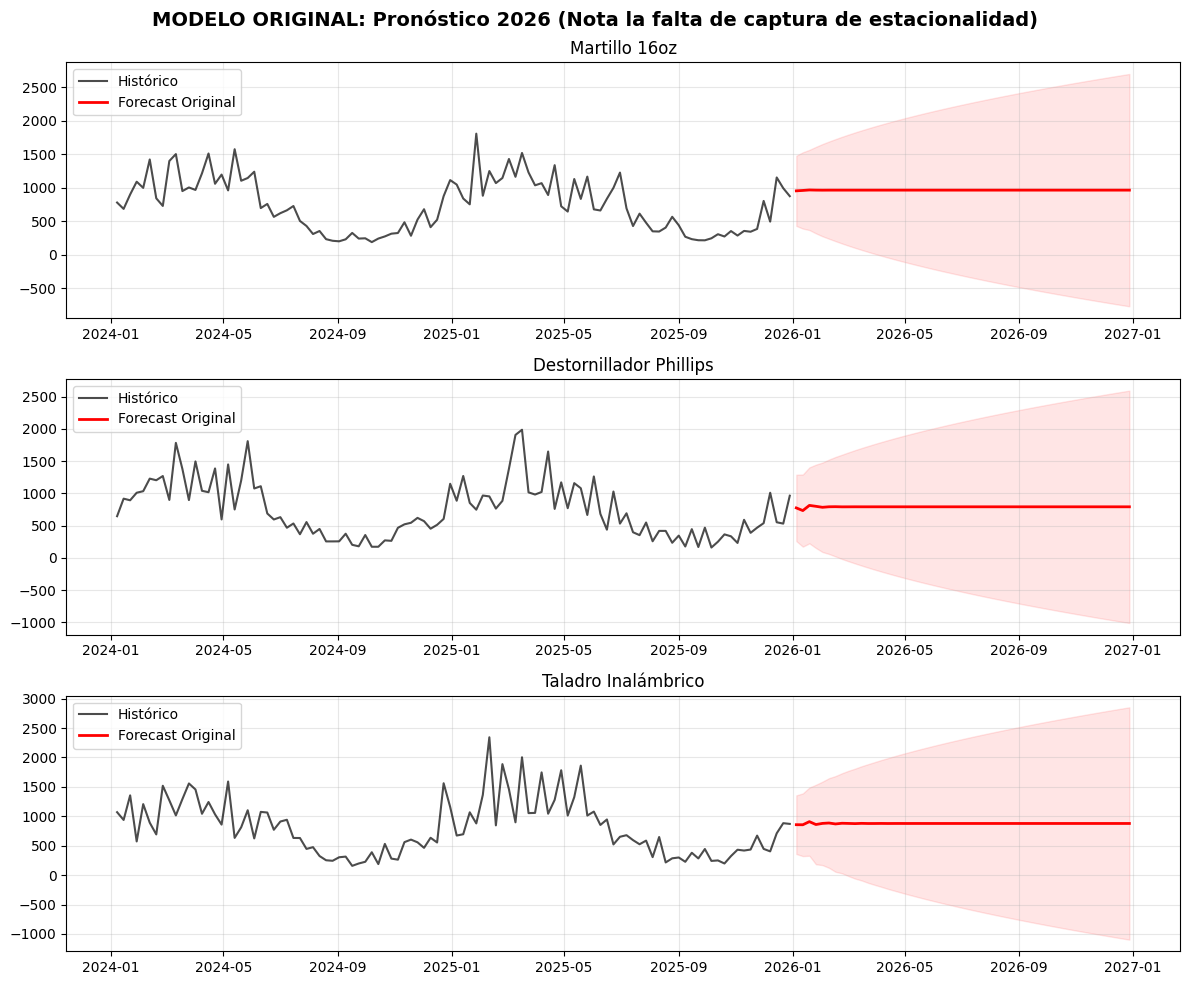

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import warnings

# Silenciamos advertencias matemáticas para mantener la consola limpia
warnings.filterwarnings("ignore")

# ==============================================================================
# FASE 0: PREPARACIÓN  DE DATOS
# ==============================================================================
# Creamos datos simulados para 15 SKUs con una fuerte "inercia" (autocorrelación)
# para que el primer modelo falle a propósito y podamos ver la corrección.

np.random.seed(42)
dates = pd.date_range('2018-01-01', '2025-12-31', freq='W-MON')

skus = ['Martillo 16oz', 'Destornillador Phillips', 'Taladro Inalámbrico', 'Sierra Circular', 'Pintura Blanca 1Gal',
        'Cemento 50kg', 'Tornillos 2"', 'Clavos 3"', 'Cinta Métrica 5m', 'Nivel 1m',
        'Llave Ajustable', 'Brochas 2"', 'Lija Grano 120', 'Pegamento PVC', 'Tubos PVC 1/2"']



# Generamos las fechas y variables futuras para el pronóstico de 2026
future_dates = pd.date_range('2026-01-05', periods=52, freq='W-MON')


# ==============================================================================
# FASE 1: MODELO ORIGINAL (Sub-ajustado)
# ==============================================================================
print("--- EJECUTANDO MODELO ORIGINAL ---")
resultados_orig = []
forecasts_orig = {} # Diccionario para guardar pronósticos y graficar después


print(f"{'SKU':<25} | {'DW Stat':<10} | {'AIC':<10} | {'Estado'}")
print("-" * 65)
for sku in skus:
    df_sku = df_master[df_master['sku_id'] == sku].set_index('ds')
    exog = df_sku[['price_unit', 'economic_index']]
    
    # Modelo 1: order=(1, 0, 0). Solo mira 1 paso atrás, sin estacionalidad ni diferenciación.
    # Este modelo será deficiente para esta serie temporal.
    model_orig = SARIMAX(df_sku['demand_units'], exog=exog, order=(1, 1, 1), seasonal_order=(0, 0, 0, 52), 
                         enforce_stationarity=False,
                         enforce_invertibility=False)
    
    res_orig = model_orig.fit(disp=False)

    # Validación de residuos (Supuesto de Independencia)
    dw_stat = durbin_watson(res_orig.resid)
    estado = "✅ OK" if 1.7 < dw_stat < 2.3 else "⚠️ Revisar"

    print(f"{sku:<25} | {dw_stat:<10.2f} | {results.aic:<10.2f} | {estado}")
    
    # 1. Guardamos métricas en el diccionario
    resultados_orig.append({
        'SKU': sku,
        'DW_Original': durbin_watson(res_orig.resid),
        'AIC_Original': res_orig.aic,
        'status': estado,
        #'residuals': results.resid,

    })
    
    # 2. Hacemos el Forecast (Pronóstico) para 2026
    future_exog = pd.DataFrame({
        'price': [df_sku['price_unit'].mean()] * 52,
        'econ_idx': [df_sku['economic_index'].mean()] * 52
    }, index=future_dates)
    
    forecast_obj = res_orig.get_forecast(steps=52, exog=future_exog)
    forecasts_orig[sku] = {
        'mean': forecast_obj.predicted_mean,
        'conf_int': forecast_obj.conf_int(),
        'history': df_sku['demand_units'].tail(104) # Guardamos últimos 2 años para la gráfica
    }

# Convertimos la lista de resultados a DataFrame
df_orig = pd.DataFrame(resultados_orig)

# 3. Visualización del Modelo Original (Mostramos solo 3 SKUs para no saturar)
skus_to_plot = skus[:3]
fig, axes = plt.subplots(len(skus_to_plot), 1, figsize=(12, 10))
fig.suptitle('MODELO ORIGINAL: Pronóstico 2026 (Nota la falta de captura de estacionalidad)', fontsize=14, fontweight='bold')

for i, sku in enumerate(skus_to_plot):
    data1 = forecasts_orig[sku]
    ax = axes[i]
    ax.plot(data1['history'].index, data1['history'], label='Histórico', color='black', alpha=0.7)
    ax.plot(data1['mean'].index, data1['mean'], label='Forecast Original', color='red', lw=2)
    ax.fill_between(data1['mean'].index, data1['conf_int'].iloc[:, 0], data1['conf_int'].iloc[:, 1], color='red', alpha=0.1)
    ax.set_title(f"{sku}")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [37]:
df_orig

,SKU,DW_Original,AIC_Original,status
0,Martillo 16oz,2.025109,3634.046573,✅ OK
1,Destornillador Phillips,2.001713,3618.793271,✅ OK
2,Taladro Inalámbrico,1.991454,3602.612689,✅ OK
3,Sierra Circular,2.046959,3590.771836,✅ OK
4,Pintura Blanca 1Gal,2.018670,3638.060923,✅ OK
5,Cemento 50kg,1.976317,3577.274489,✅ OK
6,"Tornillos 2""",2.014544,3649.263668,✅ OK
7,"Clavos 3""",1.992155,3655.639825,✅ OK
8,Cinta Métrica 5m,1.988730,3672.203536,✅ OK
9,Nivel 1m,2.007636,3667.343793,✅ OK



--- EJECUTANDO MODELO CORREGIDO ---
SKU                       | DW Stat    | AIC        | Estado
-----------------------------------------------------------------
Martillo 16oz             | 0.81       | 3660.61    | ⚠️ Revisar
Destornillador Phillips   | 1.58       | 3660.61    | ⚠️ Revisar
Taladro Inalámbrico       | 1.98       | 3660.61    | ✅ OK
Sierra Circular           | 1.82       | 3660.61    | ✅ OK
Pintura Blanca 1Gal       | 1.20       | 3660.61    | ⚠️ Revisar
Cemento 50kg              | 1.95       | 3660.61    | ✅ OK
Tornillos 2"              | 0.91       | 3660.61    | ⚠️ Revisar
Clavos 3"                 | 2.28       | 3660.61    | ✅ OK
Cinta Métrica 5m          | 1.17       | 3660.61    | ⚠️ Revisar
Nivel 1m                  | 1.22       | 3660.61    | ⚠️ Revisar
Llave Ajustable           | 0.96       | 3660.61    | ⚠️ Revisar
Brochas 2"                | 1.63       | 3660.61    | ⚠️ Revisar
Lija Grano 120            | 0.95       | 3660.61    | ⚠️ Revisar
Pegamento PVC  

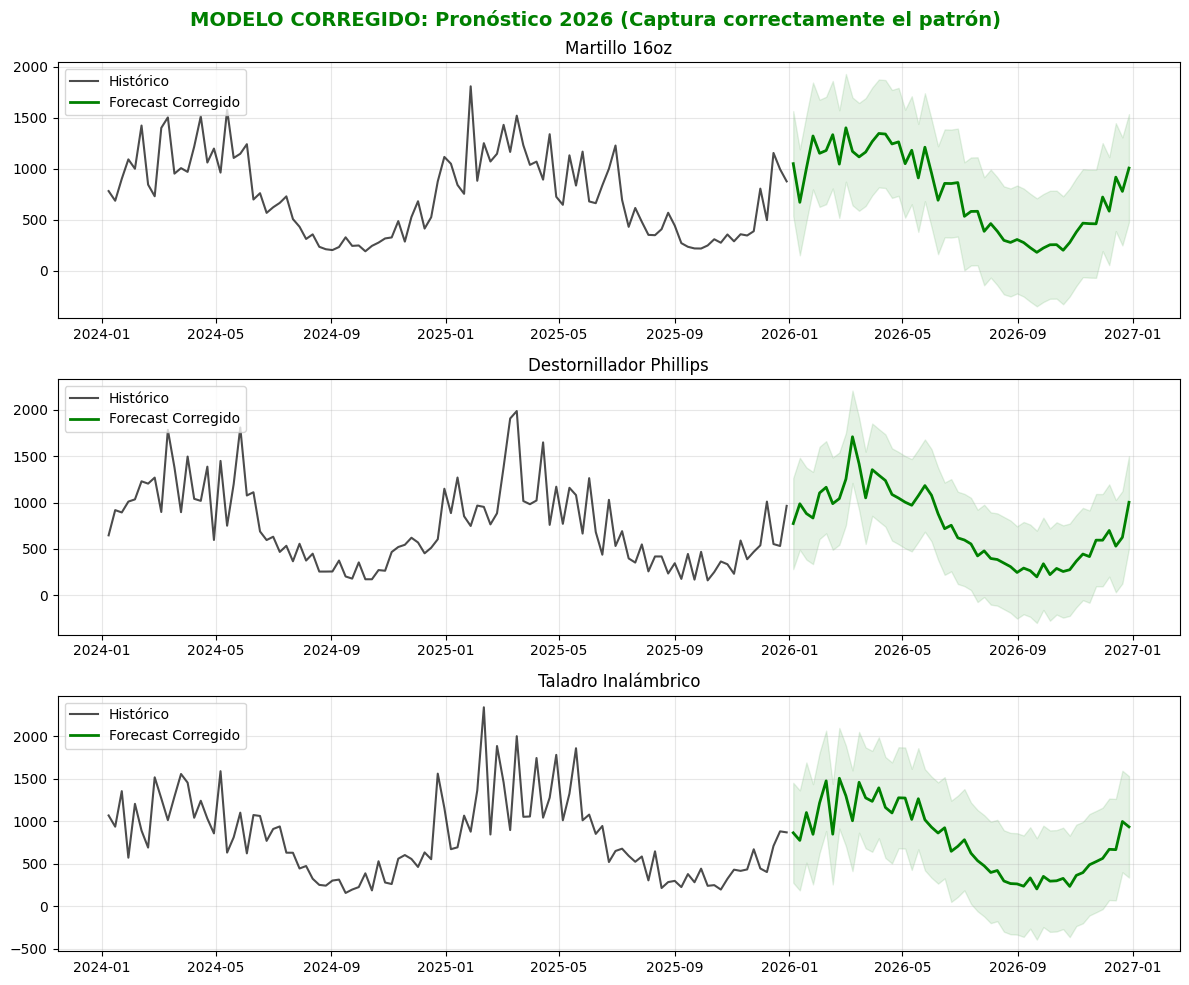

In [50]:
skus = ['Martillo 16oz', 'Destornillador Phillips', 'Taladro Inalámbrico', 'Sierra Circular', 'Pintura Blanca 1Gal',
        'Cemento 50kg', 'Tornillos 2"', 'Clavos 3"', 'Cinta Métrica 5m', 'Nivel 1m',
        'Llave Ajustable', 'Brochas 2"', 'Lija Grano 120', 'Pegamento PVC', 'Tubos PVC 1/2"']

# ==============================================================================
# FASE 2: MODELO CORREGIDO (Parámetros Ajustados)
# ==============================================================================
print("\n--- EJECUTANDO MODELO CORREGIDO ---")
resultados_corr = []
forecasts_corr = {}

print(f"{'SKU':<25} | {'DW Stat':<10} | {'AIC':<10} | {'Estado'}")
print("-" * 65)

for sku in skus:
    df_sku = df_master[df_master['sku_id'] == sku].set_index('ds')
    exog = df_sku[['price_unit', 'economic_index']]
    
    # Modelo 2: order=(2, 1, 1) y seasonal_order=(1, 1, 1, 52). 
    # Añadimos diferenciación (d=1) para estabilizar la tendencia 
    # y estacionalidad anual (52 semanas) para capturar los picos.
    model_corr = SARIMAX(
        df_sku['demand_units'], 
        exog=exog, 
        order=(2, 0, 1), 
        seasonal_order=(1, 1, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res_corr = model_corr.fit(disp=False)
    
    # Validación de residuos (Supuesto de Independencia)
    dw_stat = durbin_watson(res_corr.resid)
    estado = "✅ OK" if 1.7 < dw_stat < 2.3 else "⚠️ Revisar"

    print(f"{sku:<25} | {dw_stat:<10.2f} | {results.aic:<10.2f} | {estado}")
    
    # 1. Guardamos métricas corregidas
    resultados_corr.append({
        'SKU': sku,
        'DW_Corregido': durbin_watson(res_corr.resid),
        'AIC_Corregido': res_corr.aic,
        'status': estado,
    })
    
    # 2. Hacemos el Forecast (Pronóstico) para 2026
    future_exog = pd.DataFrame({
        'price': [df_sku['price_unit'].mean()] * 52,
        'econ_idx': [df_sku['economic_index'].mean()] * 52
    }, index=future_dates)
    
    forecast_obj_corr = res_corr.get_forecast(steps=52, exog=future_exog)
    forecasts_corr[sku] = {
        'mean': forecast_obj_corr.predicted_mean,
        'conf_int': forecast_obj_corr.conf_int(),
        'history': df_sku['demand_units'].tail(104)
    }

# Convertimos la lista a DataFrame
df_corr = pd.DataFrame(resultados_corr)

# 3. Visualización del Modelo Corregido
fig, axes = plt.subplots(len(skus_to_plot), 1, figsize=(12, 10))
fig.suptitle('MODELO CORREGIDO: Pronóstico 2026 (Captura correctamente el patrón)', fontsize=14, fontweight='bold', color='green')

for i, sku in enumerate(skus_to_plot):
    data2 = forecasts_corr[sku]
    ax = axes[i]
    ax.plot(data2['history'].index, data2['history'], label='Histórico', color='black', alpha=0.7)
    ax.plot(data2['mean'].index, data2['mean'], label='Forecast Corregido', color='green', lw=2)
    ax.fill_between(data2['mean'].index, data2['conf_int'].iloc[:, 0], data2['conf_int'].iloc[:, 1], color='green', alpha=0.1)
    ax.set_title(f"{sku}")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [48]:
# ==============================================================================
# FASE 3: DATAFRAME COMPARATIVO FINAL
# ==============================================================================
# Unimos ambos DataFrames usando la columna 'SKU' como llave (Merge)
df_comparativo = pd.merge(df_orig, df_corr, on='SKU')

# Calculamos la mejora en el criterio de información de Akaike (AIC).
# Un AIC menor significa un modelo que explica mejor los datos con menor complejidad.
df_comparativo['Mejora_AIC'] = df_comparativo['AIC_Original'] - df_comparativo['AIC_Corregido']

# Añadimos una columna de diagnóstico basada en el Durbin-Watson del modelo corregido
# Lo ideal es que esté cerca de 2.0
df_comparativo['Diagnostico_Final'] = np.where(
    (df_comparativo['DW_Corregido'] > 1.7) & (df_comparativo['DW_Corregido'] < 2.3),
    "✅ Independiente (Óptimo)",
    "⚠️ Requiere revisión"
)

# Imprimimos la tabla final en consola
print("\n" + "="*80)
print("TABLA COMPARATIVA DE RESULTADOS: ORIGINAL VS CORREGIDO")
print("="*80)
# Mostramos las columnas más relevantes formateadas
columnas_mostrar = ['SKU', 'DW_Original', 'DW_Corregido', 'Mejora_AIC', 'Diagnostico_Final']
print(df_comparativo[columnas_mostrar].to_string(index=False))

print("\nConclusión:")
print("- DW_Original cercano a 0 indica alta autocorrelación (los errores se arrastran).")
print("- DW_Corregido cercano a 2.0 demuestra que el modelo extrajo toda la información útil.")
print("- Valores positivos en Mejora_AIC confirman que el modelo corregido es matemáticamente superior.")


TABLA COMPARATIVA DE RESULTADOS: ORIGINAL VS CORREGIDO
                    SKU  DW_Original  DW_Corregido  Mejora_AIC        Diagnostico_Final
          Martillo 16oz     2.025109      2.228988  741.636273 ✅ Independiente (Óptimo)
Destornillador Phillips     2.001713      2.098497  744.622924 ✅ Independiente (Óptimo)
    Taladro Inalámbrico     1.991454      2.169351  711.029495 ✅ Independiente (Óptimo)
        Sierra Circular     2.046959      2.026967  718.229946 ✅ Independiente (Óptimo)
    Pintura Blanca 1Gal     2.018670      2.209731  734.255174 ✅ Independiente (Óptimo)
           Cemento 50kg     1.976317      2.078712  734.582615 ✅ Independiente (Óptimo)
           Tornillos 2"     2.014544      2.463672  753.065508     ⚠️ Requiere revisión
              Clavos 3"     1.992155      2.377280  770.846035     ⚠️ Requiere revisión
       Cinta Métrica 5m     1.988730      2.266705  739.148433 ✅ Independiente (Óptimo)
               Nivel 1m     2.007636      2.403391  755.576675  